# CS4603 PA4 — Document Analyst

Development & testing notebook. Section headers match the tasks in `README.md`.
Fill in each cell, run everything top-to-bottom, and **keep all outputs visible** before submitting.
Record explanations and analysis answers in `STUDENT_ANALYSIS.md`.


## Part 0 — Setup & Corpus Ingestion
Env config + ingest `data/annual_report.pdf` into Databricks Vector Search (Task 0.3).


In [0]:
# TODO(0.1): load config / verify env vars
from config import get_settings

settings = get_settings()
print("Host:", settings["host"])
print("Model:", settings["model"])
print("Embeddings endpoint:", settings["embeddings"])
print("Vector Search endpoint:", settings["vs_endpoint"])
print("Vector Search index:", settings["vs_index"])


Host: https://dbc-142d7c09-f697.cloud.databricks.com
Model: databricks-meta-llama-3-3-70b-instruct
Embeddings endpoint: databricks-gte-large-en
Vector Search endpoint: hareem-vs-endpoint
Vector Search index: cs4603.pa4.hareem_analyst_index


In [0]:
import os

notebook_path = dbutils.notebook.entry_point.getDbutils().notebook().getContext().notebookPath().get()
workspace_folder = "/Workspace" + os.path.dirname(notebook_path)
pdf_workspace_path = f"{workspace_folder}/annual_report.pdf"

print("Notebook folder:", workspace_folder)
print("Looking for PDF at:", pdf_workspace_path)

spark.sql("CREATE VOLUME IF NOT EXISTS cs4603.pa4.corpus")
volume_path = "/Volumes/cs4603/pa4/corpus"

dbutils.fs.cp(f"file:{pdf_workspace_path}", f"{volume_path}/annual_report.pdf")

display(dbutils.fs.ls(volume_path))

Notebook folder: /Workspace/Users/hareemxkhann@gmail.com/Agentic PA4
Looking for PDF at: /Workspace/Users/hareemxkhann@gmail.com/Agentic PA4/annual_report.pdf


path,name,size,modificationTime
dbfs:/Volumes/cs4603/pa4/corpus/annual_report.pdf,annual_report.pdf,22167,1783977466000


In [0]:
from rag.ingest import build_chunks_table, create_index

volume_path = "/Volumes/cs4603/pa4/corpus"

build_chunks_table(
    spark,
    volume_path=volume_path,
    chunks_table="cs4603.pa4.hareem_analyst_chunks",
)

Parsed 1 document(s) into cs4603.pa4.hareem_analyst_chunks_parsed
Chunked into 7 rows in cs4603.pa4.hareem_analyst_chunks
+-------------------------------------------------+--------+
|source                                           |n_chunks|
+-------------------------------------------------+--------+
|dbfs:/Volumes/cs4603/pa4/corpus/annual_report.pdf|7       |
+-------------------------------------------------+--------+



In [0]:
%pip install databricks-vectorsearch

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
create_index()

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
Endpoint 'hareem-vs-endpoint' already exists, reusing it.
Index 'cs4603.pa4.hareem_analyst_index' already exists — will sync after ready.
Index status: ONLINE_UPDATING_PIPELINE_RESOURCES
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
Smoke-test similarity search results:
['8930f635ba3f43a28461672a24c24434_0', '\nAnnual Report\n\nFor the fiscal year ended March 31, 2023 (FY2023)\n\nTokyo Stock Exchange (Prime Market) · Code 7000\n\n<table><tr><td>Letter from the President and CEO</td><td>3</td></tr><tr><td>Financial Highlights — Five-Year Summary</td><td>4</td></tr><tr><td>Consolidated Statement of Operations</td><td>5</

## Part 1 — Build the Document Analyst graph
Nodes: planner (1.2), supervisor (1.3), RAG agent (1.4), MCP tools (1.5), synthesizer (1.6), full graph (1.7).


In [0]:
import importlib
import sys

import agent.graph as graph_module
importlib.reload(graph_module)
from agent.graph import build_graph

graph = build_graph()


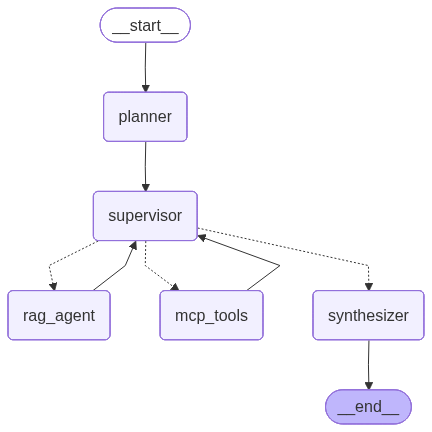

In [0]:
# TODO(1.7): visualize the compiled graph
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())



### Test the graph


In [0]:
# Retrieval-only query
graph.invoke({
    "messages": [{"role": "user", "content": "What was the net income in 2023?"}],
    "plan": [],
    "current_step_index": 0,
    "step_results": [],
    "next_agent": "",
    "final_answer": "",
})


[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


{'messages': [HumanMessage(content='What was the net income in 2023?', additional_kwargs={}, response_metadata={}, id='6dcdcf84-2852-43e6-83de-292bbce3adfa'),
  AIMessage(content='The net income in 2023 was ¥1,107 billion, as reported in the annual report [source: dbfs:/Volumes/cs4603/pa4/corpus/annual_report.pdf, p.None].', additional_kwargs={}, response_metadata={}, id='4fb73f26-7297-48ee-b9e5-694bfa768ced', tool_calls=[], invalid_tool_calls=[])],
 'plan': ['Find the net income for fiscal year 2023 in the financial document'],
 'current_step_index': 1,
 'step_results': ["Step 1 ('Find the net income for fiscal year 2023 in the financial document'): The net income for fiscal year 2023 is ¥1,107 billion [source: dbfs:/Volumes/cs4603/pa4/corpus/annual_report.pdf, p.None]."],
 'next_agent': 'synthesizer',
 'final_answer': 'The net income in 2023 was ¥1,107 billion, as reported in the annual report [source: dbfs:/Volumes/cs4603/pa4/corpus/annual_report.pdf, p.None].'}

In [0]:
# Computation-only query
graph.invoke({
    "messages": [{"role": "user", "content": "What is 15% of 2.4 billion?"}],
    "plan": [],
    "current_step_index": 0,
    "step_results": [],
    "next_agent": "",
    "final_answer": "",
})


{'messages': [HumanMessage(content='What is 15% of 2.4 billion?', additional_kwargs={}, response_metadata={}, id='bfef42cd-ce8f-4b10-aadb-5b3a61906445'),
  AIMessage(content='Unfortunately, due to errors in the calculation process [source: Step 1 and Step 2 error reports], the exact value of 15% of 2.4 billion could not be determined. The errors occurred during the invocation of the \'unit_convert\' tool, which prevented the calculation from being completed [source: Step 1 and Step 2 error reports]. As a result, the answer to the question "What is 15% of 2.4 billion?" cannot be provided based on the available step results.', additional_kwargs={}, response_metadata={}, id='8bdf2d14-26a0-4a9a-b129-fa90ea6d3f30', tool_calls=[], invalid_tool_calls=[])],
 'plan': ['Define the principal amount as 2.4 billion',
  'Calculate 15% of the principal amount'],
 'current_step_index': 2,
 'step_results': ["Step 1 ('Define the principal amount as 2.4 billion'): Error calling tool 'unit_convert': Struc

In [0]:
# Combined query — show the full step-by-step execution trace
result = graph.invoke({
    "messages": [{"role": "user", "content": "What was the revenue in 2023, and what would a 10% increase look like?"}],
    "plan": [],
    "current_step_index": 0,
    "step_results": [],
    "next_agent": "",
    "final_answer": "",
})

print("PLAN:")
for i, step in enumerate(result["plan"], start=1):
    print(f"  {i}. {step}")

print("\nSTEP RESULTS:")
for r in result["step_results"]:
    print(f"  - {r}")

print("\nFINAL ANSWER:")
print(result["final_answer"])


[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
PLAN:
  1. Find the company's net revenue for fiscal year 2023
  2. Calculate a 10% increase on the FY2023 net revenue found in step 1
  3. Present both the original FY2023 revenue and the calculated increased revenue

STEP RESULTS:
  - Step 1 ('Find the company's net revenue for fiscal year 2023'): The company's net revenue for fiscal year 2023 was ¥16,910 billion. [source: dbfs:/Volumes/cs4603/pa4/corpus/annual_report.pdf, p.None]
  - Step 2 ('Calculate a 10% increase on the FY2023 net revenue found in step 1'): Error calling tool 'calculate': StructuredTool does not support sync invocation.
  - Step 3 ('Present both the original FY2023 revenue and the calculated increased revenue'): Error calling tool 'calculate': StructuredTool does not support sync invocation.

FINAL ANSWER:

### Required — offline smoke test
Runs the graph with a mocked LLM (no Databricks calls). Same test Bonus A automates.


In [0]:
!python -m pytest tests/test_smoke.py -q


...                                                                      [100%]


## Part 2 — Deployment
Package as an MLflow models-from-code model, register in Unity Catalog, create the serving endpoint (Tasks 2.1–2.4).
Reference: `databricks_deployment_v1/deployment.ipynb`.


In [0]:
%pip install databricks-vectorsearch databricks-langchain databricks-sdk langchain-mcp-adapters mcp openai python-dotenv nest_asyncio
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# TODO(2.1): sanity-check the model definition imports cleanly
!python -c "import deployment.agent_model"



Fri Jul 17 12:05:11 2026 Connection to spark using Py4J from PID  529
Fri Jul 17 12:05:11 2026 Initialized gateway on port 42541
/databricks/python_shell/lib/third_party/python/vendor/protobuf/google/protobuf/internal/api_implementation.py:120: UserWarning: Selected implementation upb is not available. Falling back to the python implementation.
  warnings.warn('Selected implementation upb is not available. '
Fri Jul 17 12:05:11 2026 Connected to spark using Py4J in SparkMode.REMOTE_CONNECT mode.


In [0]:
# TODO(2.2): log + register the model version in Unity Catalog
from dotenv import load_dotenv
load_dotenv()

from deployment.deploy import log_and_register

uc_name, version = log_and_register()
print(f"Registered model: {uc_name}")
print(f"Version: {version}")



If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc
🔗 View Logged Model at: https://dbc-142d7c09-f697.cloud.databricks.com/ml/experiments/1545848163969398/models/m-889c557421b249929dc5154bf7ae84f1?o=7474644904229912
/local_disk0/.ephemeral_nfs/envs/pythonEnv-d8e8a80c-5f9b-4406-a882-7e9def4cf888/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouteDecision(next_agent='rag_agent'), input_type=RouteDecision])
  return self.__pydantic_serializer__.to_python(


[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


/local_disk0/.ephemeral_nfs/envs/pythonEnv-d8e8a80c-5f9b-4406-a882-7e9def4cf888/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/17 14:15:50 INFO mlflow: Attempting to auto-detect Databricks resource dependencies for the current langchain model. Dependency auto-detection is best-effort and may not c

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


2026/07/17 14:15:57 INFO mlflow.models.model: Found the following environment variables used during model inference: [DATABRICKS_HOST, DATABRICKS_TOKEN]. Please check if you need to set them when deploying the model. To disable this message, set environment variable `MLFLOW_RECORD_ENV_VARS_IN_MODEL_LOGGING` to `false`.
Registered model 'cs4603.pa4.hareem_document_analyst' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/28 [00:00<?, ?it/s]

Registered model: cs4603.pa4.hareem_document_analyst, version 7
Registered model: cs4603.pa4.hareem_document_analyst
Version: 7


🔗 Created version '7' of model 'cs4603.pa4.hareem_document_analyst': https://dbc-142d7c09-f697.cloud.databricks.com/explore/data/models/cs4603/pa4/hareem_document_analyst/version/7?o=7474644904229912


In [0]:
# TODO(2.3): create/update the serving endpoint; wait for READY; print the URL

from deployment.deploy import create_or_update_endpoint

endpoint_url = create_or_update_endpoint(uc_name, version)
print(f"Endpoint URL: {endpoint_url}")

Endpoint 'hareem-document-analyst' exists — updating served entities...
Endpoint READY: https://dbc-142d7c09-f697.cloud.databricks.com/serving-endpoints/hareem-document-analyst/invocations
Endpoint URL: https://dbc-142d7c09-f697.cloud.databricks.com/serving-endpoints/hareem-document-analyst/invocations


### Test the deployed endpoint (Task 2.4)


In [0]:
# curl the endpoint and show the raw response
import json
import os

host = os.environ["DATABRICKS_HOST"].rstrip("/")
token = os.environ["DATABRICKS_TOKEN"]
endpoint_name = os.environ["SERVING_ENDPOINT_NAME"]

url = f"{host}/serving-endpoints/{endpoint_name}/invocations"
payload = json.dumps({"messages": [{"role": "user", "content": "What was the net income in 2023?"}]})

cmd = (
    f"curl -s -X POST '{url}' "
    f"-H 'Authorization: Bearer {token}' "
    f"-H 'Content-Type: application/json' "
    f"-d '{payload}'"
)
!{cmd}


[{"messages": [{"content": "What was the net income in 2023?", "additional_kwargs": {}, "response_metadata": {}, "type": "human", "name": null, "id": "27e7d83e-0d04-4220-b233-0d7ecf1b598f"}, {"content": "The net income in 2023 was \u00a51,107 billion, as reported in the annual report [source: dbfs:/Volumes/cs4603/pa4/corpus/annual_report.pdf, p.None].", "additional_kwargs": {}, "response_metadata": {}, "type": "ai", "name": null, "id": "7058eaa8-6145-4fa5-adb1-cea4459d203a", "tool_calls": [], "invalid_tool_calls": [], "usage_metadata": null}], "plan": ["Find the net income for fiscal year 2023 in the financial document"], "current_step_index": 1, "step_results": ["Step 1 ('Find the net income for fiscal year 2023 in the financial document'): The net income for fiscal year 2023 is \u00a51,107 billion [source: dbfs:/Volumes/cs4603/pa4/corpus/annual_report.pdf, p.None]."], "next_agent": "synthesizer", "final_answer": "The net income in 2023 was \u00a51,107 billion, as reported in the annu

In [0]:
import os
import requests



resp = requests.post(
    f"{host}/serving-endpoints/{endpoint_name}/invocations",
    headers={"Authorization": f"Bearer {token}", "Content-Type": "application/json"},
    json={"messages": [{"role": "user", "content": "What was the net income in 2023?"}]},
)
resp.raise_for_status()
result = resp.json()
print(result[0]["final_answer"])

The net income in 2023 was ¥1,107 billion, as reported in the annual report [source: dbfs:/Volumes/cs4603/pa4/corpus/annual_report.pdf, p.None].


## Part 3 — Client SDK demo
Instantiate `DocumentAnalystClient`, health-check, ask, stream, and show timeout/retry handling (Task 3.2).


In [1]:
from client.sdk import DocumentAnalystClient
import os

endpoint_name = os.environ.get("SERVING_ENDPOINT_NAME", "hareem-document-analyst")
c = DocumentAnalystClient(endpoint_name=endpoint_name)

assert c.health_check() is True
print(c.ask("What was the net income in 2023?"))


The net income in 2023 was ¥1,107 billion, as reported in the annual report [source: dbfs:/Volumes/cs4603/pa4/corpus/annual_report.pdf, p.None].


In [2]:
# ask_streaming demo
for chunk in c.ask_streaming('Summarize FY2023 revenue.'): print(chunk, end='')



The total revenue for FY2023 is ¥16,910 billion [source: dbfs:/Volumes/cs4603/pa4/corpus/annual_report.pdf, p.None]. However, due to an error, the percentage change in revenue compared to the previous fiscal year could not be determined. Therefore, only the absolute revenue figure for FY2023 is available.

In [ ]:
# Simulate timeout (timeout=0.001) and endpoint-unavailable retry behavior
# Simulate timeout (timeout=0.001) and endpoint-unavailable retry behavior
from client.sdk import AnalystClientError, DocumentAnalystClient

timeout_client = DocumentAnalystClient(
    endpoint_name=os.environ["SERVING_ENDPOINT_NAME"], timeout=0.001
)
try:
    timeout_client.ask("What was the net income in 2023?")
except TimeoutError as e:
    print(f"Caught expected TimeoutError: {e}")

# Simulate the endpoint being unavailable by pointing at a nonexistent name.
# The client retries 429/503 with exponential backoff before raising.
bad_client = DocumentAnalystClient(endpoint_name="this-endpoint-does-not-exist", max_retries=2)
try:
    bad_client.ask("What was the net income in 2023?")
except AnalystClientError as e:
    print(f"Caught expected AnalystClientError: status={e.status_code}, message={e}")



Caught expected TimeoutError: Request to 'hareem-document-analyst' timed out after 0.187s
Caught expected AnalystClientError: status=404, message=The given endpoint does not exist, please retry after checking the specified model and version deployment exists. (status_code=404, request_id=f2f96193-2f74-4391-92fc-8629ede33875)


: 